# FlashEats — Class 7 Challenge
## Model the Business Workflow with Data

### Client question
> **“Show us where in the workflow delay accumulates, how customers react, what interventions we make, and which metrics we should use to improve the project KPI.”**

Do not repeat source discovery, retrieval, or data-cleaning work. Today the goal is to build a useful business-workflow model.

In [1]:
import json, sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

# The notebook runs from exercises/, the classroom pack sits next to it
BASE = Path("FlashEats_Classroom_Pack_V2")
DB_PATH = BASE / "database" / "flasheats.db"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DB_PATH}. Run this notebook from the folder that contains FlashEats_Classroom_Pack_V2."
    )
print("BASE:", BASE)
print("Database found:", DB_PATH.exists())

BASE: FlashEats_Classroom_Pack_V2
Database found: True


In [2]:
con=sqlite3.connect(BASE/"database"/"flasheats.db")
orders=pd.read_sql("SELECT * FROM orders",con)
customers=pd.read_sql("SELECT * FROM customers",con)
restaurants=pd.read_sql("SELECT * FROM restaurants",con)
drivers=pd.read_sql("SELECT * FROM drivers",con)
tickets=pd.read_csv(BASE/"data"/"support_tickets.csv")
customer_actions=pd.read_csv(BASE/"data"/"customer_app_actions.csv")
interventions=pd.read_csv(BASE/"data"/"order_interventions.csv")
outcomes=pd.read_csv(BASE/"data"/"order_outcomes.csv")
with open(BASE/"data"/"class7_model_brief.json") as f: model_brief=json.load(f)
print("orders",orders.shape,"actions",customer_actions.shape,"interventions",interventions.shape,"outcomes",outcomes.shape)
print("Project KPI:",model_brief["project_kpi"])

orders (1603, 13) actions (2365, 6) interventions (430, 6) outcomes (1600, 6)
Project KPI: Reduce late delivery rate


In [3]:
# extra sources for the timeline
order_events = pd.read_csv(BASE / "data" / "order_events.csv")
interactions = pd.read_csv(BASE / "data" / "customer_interactions.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
with open(BASE / "data" / "driver_events.json") as f:
    driver_events = pd.DataFrame([{"driver_id": d["driver_id"], **e} for d in json.load(f) for e in d["events"]])
print("order_events", order_events.shape, "| interactions", interactions.shape,
      "| restaurant_status", restaurant_status.shape, "| driver_events", driver_events.shape)
print(model_brief["business_question"])

order_events (4955, 7) | interactions (497, 6) | restaurant_status (502, 4) | driver_events (10035, 6)
Where in the order lifecycle do delays accumulate, and which interventions are associated with better outcomes?


# Challenge 1 — Reconstruct the order lifecycle

Choose 3 orders:
- one delivered on time,
- one delivered late,
- one with an intervention.

Build a timeline with:

`event_time | event_type | actor | source_system`

Include as many lifecycle events as the data supports.

### Hint
Start from one `order_id`, collect events from each source, then sort by time.

In [4]:
base_orders = orders.drop_duplicates("order_id", keep="first")   # 3 duplicate rows, keep first
has_intervention = set(interventions["order_id"])

# late / on-time orders WITHOUT any intervention, so the three examples are really different
late_order = outcomes[(outcomes.late_flag == 1) & ~outcomes.order_id.isin(has_intervention)].order_id.iloc[0]
on_time_order = outcomes[(outcomes.late_flag == 0) & ~outcomes.order_id.isin(has_intervention)].order_id.iloc[0]

# intervention order: first one where the intervention happened before delivery and the customer also raised a ticket
iv_times = interventions.merge(base_orders[["order_id", "actual_delivery_at"]], on="order_id")
before_delivery = iv_times[pd.to_datetime(iv_times["intervention_at"], format="mixed")
                           < pd.to_datetime(iv_times["actual_delivery_at"], format="mixed")]
intervention_order = before_delivery[before_delivery.order_id.isin(tickets.order_id)].order_id.iloc[0]
print("late", late_order, "| on-time", on_time_order, "| intervention", intervention_order)

late O00002 | on-time O00003 | intervention O01362


In [5]:
def build_order_timeline(order_id):
    parts = []

    o = base_orders[base_orders.order_id == order_id]
    parts.append(pd.DataFrame({"event_time": o["promised_eta"], "event_type": "PROMISED_ETA (deadline)",
                               "actor": "platform", "source_system": "orders (sqlite)"}))

    ev = order_events[order_events.order_id == order_id]
    parts.append(pd.DataFrame({"event_time": ev["event_time"], "event_type": ev["event_type"],
                               "actor": ev["actor_type"] + ":" + ev["actor_id"].fillna("?"),
                               "source_system": "order_events/" + ev["source_system"]}))

    de = driver_events[driver_events.order_id == order_id]
    parts.append(pd.DataFrame({"event_time": de["timestamp"], "event_type": "DRIVER_" + de["type"].str.upper(),
                               "actor": "driver:" + de["driver_id"], "source_system": "driver_app"}))

    rs = restaurant_status[restaurant_status.order_id == order_id].drop_duplicates()
    parts.append(pd.DataFrame({"event_time": rs["last_updated_at"],
                               "event_type": "RESTAURANT_STATUS = " + rs["status"].str.strip(),
                               "actor": "restaurant:" + rs["restaurant_id"], "source_system": "restaurant_status"}))

    ca = customer_actions[customer_actions.order_id == order_id]
    parts.append(pd.DataFrame({"event_time": ca["action_at"], "event_type": ca["action_type"],
                               "actor": "customer:" + ca["customer_id"], "source_system": "customer_app_actions"}))

    # SUPPORT_TICKET rows in customer_interactions repeat support_tickets.csv, so take tickets from one place only
    ci = interactions[(interactions.order_id == order_id) & (interactions.interaction_type != "SUPPORT_TICKET")]
    parts.append(pd.DataFrame({"event_time": ci["interaction_at"], "event_type": ci["interaction_type"],
                               "actor": "customer", "source_system": "customer_interactions"}))

    tk = tickets[tickets.order_id == order_id].drop_duplicates()
    parts.append(pd.DataFrame({"event_time": tk["created_at"],
                               "event_type": "SUPPORT_TICKET (" + tk["category"].str.strip() + ")",
                               "actor": "customer", "source_system": "support_tickets"}))

    iv = interventions[interventions.order_id == order_id]
    parts.append(pd.DataFrame({"event_time": iv["intervention_at"],
                               "event_type": "INTERVENTION " + iv["intervention_type"] + " (" + iv["reason"] + ")",
                               "actor": iv["initiated_by"], "source_system": "order_interventions"}))

    # outcomes has no timestamp, so I pin it to the delivery time
    oc = outcomes[outcomes.order_id == order_id]
    parts.append(pd.DataFrame({"event_time": o["actual_delivery_at"].values,
                               "event_type": "OUTCOME " + oc["outcome_bucket"] + " (delay " + oc["delay_min"].astype(str) + " min)",
                               "actor": "derived", "source_system": "order_outcomes"}))

    tl = pd.concat(parts, ignore_index=True)
    tl["event_time"] = pd.to_datetime(tl["event_time"], format="mixed", errors="coerce")
    return tl.sort_values("event_time", na_position="last", kind="stable").reset_index(drop=True)


for label, oid in [("ON TIME", on_time_order), ("LATE", late_order), ("INTERVENTION", intervention_order)]:
    print(f"\n=== {label}: {oid} ===")
    display(build_order_timeline(oid))


=== ON TIME: O00003 ===


,event_time,event_type,actor,source_system
0,2026-08-01 19:35:00.000000,ORDER_CREATED,customer:C0855,order_events/order_platform
1,2026-08-01 19:35:00.002443,DRIVER_ASSIGNED,driver:D039,driver_app
2,2026-08-01 19:44:37.017130,DRIVER_GPS_PING,driver:D039,driver_app
3,2026-08-01 19:48:00.000000,RESTAURANT_STATUS = preparing,restaurant:R010,restaurant_status
4,2026-08-01 19:54:14.031817,DRIVER_GPS_PING,driver:D039,driver_app
5,2026-08-01 19:57:50.820366,PICKED_UP,driver:D039,order_events/order_platform
6,2026-08-01 19:57:50.820366,DRIVER_PICKED_UP,driver:D039,driver_app
7,2026-08-01 20:03:51.046504,DRIVER_GPS_PING,driver:D039,driver_app
8,2026-08-01 20:13:28.061191,DELIVERED,driver:D039,order_events/order_platform
9,2026-08-01 20:13:28.061191,DRIVER_DELIVERED,driver:D039,driver_app



=== LATE: O00002 ===


,event_time,event_type,actor,source_system
0,2026-08-01 18:36:00.000000,ORDER_CREATED,customer:C0043,order_events/order_platform
1,2026-08-01 18:37:09.708219,DRIVER_ASSIGNED,driver:D083,driver_app
2,2026-08-01 18:48:50.559938,DRIVER_GPS_PING,driver:D083,driver_app
3,2026-08-01 18:58:24.735336,PICKED_UP,driver:D083,order_events/order_platform
4,2026-08-01 18:58:24.735336,DRIVER_PICKED_UP,driver:D083,driver_app
5,2026-08-01 19:00:31.411657,DRIVER_GPS_PING,driver:D083,driver_app
6,2026-08-01 19:12:12.263376,DRIVER_GPS_PING,driver:D083,driver_app
7,2026-08-01 19:23:53.115095,DRIVER_GPS_PING,driver:D083,driver_app
8,2026-08-01 19:35:33.966814,DRIVER_GPS_PING,driver:D083,driver_app
9,2026-08-01 19:43:16.627988,PROMISED_ETA (deadline),platform,orders (sqlite)



=== INTERVENTION: O01362 ===


,event_time,event_type,actor,source_system
0,2026-08-10 20:08:00.000000,ORDER_CREATED,customer:C0448,order_events/order_platform
1,2026-08-10 20:09:17.874614,DRIVER_ASSIGNED,driver:D048,driver_app
2,2026-08-10 20:20:00.000000,RESTAURANT_STATUS = ready,restaurant:R020,restaurant_status
3,2026-08-10 20:31:30.495591,DRIVER_GPS_PING,driver:D048,driver_app
4,2026-08-10 20:34:00.000000,INTERVENTION DRIVER_REASSIGNMENT (driver_unavailable),dispatch,order_interventions
5,2026-08-10 20:45:44.371040,PICKED_UP,driver:D048,order_events/order_platform
6,2026-08-10 20:45:44.371040,DRIVER_PICKED_UP,driver:D048,driver_app
7,2026-08-10 20:47:00.000000,SUPPORT_TICKET (late_delivery),customer,support_tickets
8,2026-08-10 20:53:43.116568,DRIVER_GPS_PING,driver:D048,driver_app
9,2026-08-10 21:15:55.737546,DRIVER_GPS_PING,driver:D048,driver_app


In [6]:
# minutes between the main steps for the three orders
def phases(order_id):
    tl = build_order_timeline(order_id).set_index("event_type")["event_time"]
    t = lambda k: tl[tl.index == k].min() if k in tl.index else pd.NaT
    created, assigned, picked, delivered = t("ORDER_CREATED"), t("DRIVER_ASSIGNED"), t("PICKED_UP"), t("DELIVERED")
    mins = lambda a, b: round((b - a).total_seconds() / 60, 1)
    return {"order_id": order_id, "created->assigned": mins(created, assigned),
            "assigned->picked_up": mins(assigned, picked), "picked_up->delivered": mins(picked, delivered),
            "delay_vs_promise": outcomes.set_index("order_id").loc[order_id, "delay_min"]}

display(pd.DataFrame([phases(x) for x in [on_time_order, late_order, intervention_order]]))

,order_id,created->assigned,assigned->picked_up,picked_up->delivered,delay_vs_promise
0,O00003,0.0,22.8,15.6,-4.41
1,O00002,1.2,21.3,48.8,3.97
2,O01362,1.3,36.4,52.4,12.83


I picked the late and on-time orders among orders with no intervention so the three are different.

- **O00003 (on time):** picked up 22.8 min after assignment, 15.6 min ride, 4.41 min early.
- **O00002 (late):** pickup 21.3 min after assignment, but a 48.8 min ride (severe traffic bucket). 3.97 min late.
- **O01362 (intervention):** restaurant "ready" at 20:20, pickup only at 20:45 (36.4 min after assignment). A DRIVER_REASSIGNMENT was logged at 20:34 but the same driver D048 picked up. Ticket at 20:47, delivered 12.83 min late.

order_events and the driver app agree on pickup/delivery here. Between assignment and pickup we only have a few GPS pings, so we can't see what happened in that gap. Outcomes have no timestamp, so I placed them at delivery.

# Challenge 2 — Define the canonical project model

Your model must support:
1. customer → orders
2. order → customer interactions
3. order → support interactions
4. order → interventions
5. order → outcome

For each table, document:
- primary key,
- important foreign keys,
- grain.

Then explain why this model is better for the project than mirroring every source-system table.

In [7]:
sources = {"orders": orders, "customer_actions": customer_actions, "support_tickets": tickets,
           "interventions": interventions, "outcomes": outcomes}
for name, df in sources.items():
    print(name, df.shape); display(df.head(2))

orders (1603, 13)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear


customer_actions (2365, 6)


,action_id,order_id,customer_id,action_type,action_at,channel
0,ACT-00001,O01044,C0249,ETA_VIEWED,2026-08-05T22:11:00,mobile_app
1,ACT-00002,O01334,C0692,ETA_VIEWED,2026-08-01T17:48:00,mobile_app


support_tickets (202, 5)


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.


interventions (430, 6)


,intervention_id,order_id,intervention_type,intervention_at,initiated_by,reason
0,INT-00001,O00781,PRIORITY_DISPATCH,2026-08-22T12:57:00,operations,late_risk
1,INT-00002,O01476,CUSTOMER_CREDIT,2026-08-01T23:46:36.200640,support,support_resolution


outcomes (1600, 6)


,order_id,final_status_norm,delivered_flag,late_flag,delay_min,outcome_bucket
0,O00001,delivered,1,1.0,10.82,delivered_late
1,O00002,delivered,1,1.0,3.97,delivered_late


In [8]:
order_ids = set(orders.order_id)

def key_profile(name, df, pk, fks):
    row = {"table": name, "rows": len(df), "candidate_pk": pk,
           "pk_unique": df[pk].is_unique, "pk_duplicates": int(df[pk].duplicated().sum())}
    for fk, parent in fks.items():
        row[f"{fk} null"] = int(df[fk].isna().sum())
        row[f"{fk} matched %"] = round(100 * df[fk].dropna().isin(parent).mean(), 2)
    return row

cust_ids = set(customers.customer_id)
profile = pd.DataFrame([
    key_profile("customers", customers, "customer_id", {}),
    key_profile("orders", orders, "order_id", {"customer_id": cust_ids}),
    key_profile("customer_app_actions", customer_actions, "action_id", {"order_id": order_ids}),
    key_profile("customer_interactions", interactions, "interaction_id", {"order_id": order_ids}),
    key_profile("support_tickets", tickets, "ticket_id", {"order_id": order_ids}),
    key_profile("order_interventions", interventions, "intervention_id", {"order_id": order_ids}),
    key_profile("order_outcomes", outcomes, "order_id", {"order_id": order_ids}),
    key_profile("order_events", order_events, "event_id", {"order_id": order_ids}),
])
display(profile)

# how many rows per order in each child table (tells me the grain / cardinality)
per_order = pd.DataFrame({
    name: df.groupby("order_id").size().describe()[["count", "mean", "max"]]
    for name, df in {"customer_app_actions": customer_actions, "support_tickets": tickets.drop_duplicates(),
                     "order_interventions": interventions, "order_events": order_events, "order_outcomes": outcomes}.items()
}).T.round(2)
display(per_order)

# a few consistency checks between sources
chk = customer_actions.merge(base_orders[["order_id", "customer_id"]], on="order_id", suffixes=("_action", "_order"))
print("app actions whose customer_id disagrees with the order:", int((chk.customer_id_action != chk.customer_id_order).sum()))
print("duplicated interaction_ids:", interactions[interactions.interaction_id.duplicated(keep=False)].interaction_id.unique().tolist())
st = interactions[interactions.interaction_type == "SUPPORT_TICKET"].merge(
    tickets.drop_duplicates(), left_on=["order_id", "interaction_at"], right_on=["order_id", "created_at"], how="left")
print("SUPPORT_TICKET interactions that also exist in support_tickets.csv:", int(st.ticket_id.notna().sum()),
      "of", len(st))
ev_iv = order_events[order_events.source_system == "interventions"]
m = ev_iv.merge(interventions, left_on=["order_id", "event_type"], right_on=["order_id", "intervention_type"])
# driver app 'assigned' uses the current driver, orders.driver_id keeps the original one
drv_now = driver_events[driver_events.type == "assigned"][["order_id", "driver_id"]].merge(
    base_orders[["order_id", "driver_id"]], on="order_id", suffixes=("_app", "_orders"))
changed = set(drv_now[drv_now.driver_id_orders.notna() & (drv_now.driver_id_app != drv_now.driver_id_orders)].order_id)
ra = interventions[interventions.intervention_type == "DRIVER_REASSIGNMENT"]
print("orders where the driver changed:", len(changed),
      "| DRIVER_REASSIGNMENT interventions on those orders:", int(ra.order_id.isin(changed).sum()), "of", len(ra))
print("intervention events in order_events:", len(ev_iv), "| of those matching order_interventions on order+type:", len(m),
      "| rows in order_interventions:", len(interventions))

,table,rows,candidate_pk,pk_unique,pk_duplicates,customer_id null,customer_id matched %,order_id null,order_id matched %
0,customers,900,customer_id,True,0,NaN,NaN,NaN,NaN
1,orders,1603,order_id,False,3,0.0,100.0,NaN,NaN
2,customer_app_actions,2365,action_id,True,0,NaN,NaN,0.0,100.0
3,customer_interactions,497,interaction_id,False,3,NaN,NaN,0.0,100.0
4,support_tickets,202,ticket_id,False,1,NaN,NaN,3.0,100.0
5,order_interventions,430,intervention_id,True,0,NaN,NaN,0.0,100.0
6,order_outcomes,1600,order_id,True,0,NaN,NaN,0.0,100.0
7,order_events,4955,event_id,True,0,NaN,NaN,0.0,100.0


,count,mean,max
customer_app_actions,1100.0,2.15,5.0
support_tickets,198.0,1.00,1.0
order_interventions,430.0,1.00,1.0
order_events,1600.0,3.10,4.0
order_outcomes,1600.0,1.00,1.0


app actions whose customer_id disagrees with the order: 0
duplicated interaction_ids: ['CI-0178', 'CI-0179', 'CI-0180']
SUPPORT_TICKET interactions that also exist in support_tickets.csv: 177 of 177
orders where the driver changed: 95 | DRIVER_REASSIGNMENT interventions on those orders: 8 of 155
intervention events in order_events: 260 | of those matching order_interventions on order+type: 15 | rows in order_interventions: 430


| Table | Grain | PK | FKs |
|---|---|---|---|
| customer | one customer | customer_id | - |
| order | one order (after dedup) | order_id | customer_id, restaurant_id, driver_id |
| order_event | one lifecycle event | event_id | order_id |
| customer_interaction | one app action / interaction | source + id (interaction_id has 3 repeats) | order_id, customer_id |
| support_ticket | one ticket | ticket_id (1 duplicate row dropped) | order_id |
| intervention | one intervention | intervention_id | order_id |
| order_outcome | one per order | order_id | order_id (1:1) |

Customer 1-N order; order 1-N events, interactions, tickets, interventions; order 1-1 outcome.

The 177 SUPPORT_TICKET interactions are the same tickets as support_tickets.csv, so I keep them once. order_events has its own intervention log that barely matches order_interventions, so I use order_interventions and flag it.

Why not mirror the sources: everything hangs off the order (the KPI grain), each fact lives in one place so nothing is double counted, and each table has one grain so joins stay safe.

# Challenge 3 — Build interaction → intervention → outcome

Create one order-level table containing:

`order_id, customer_id, support_opened, cancel_attempted, intervention_count, intervention_types, final_status, late_flag, delay_min`

Answer:
1. How many late orders had support interaction?
2. How many orders received intervention?
3. Which intervention is most common?
4. Which frustrated journeys had no intervention?

### Hint
Aggregate one-to-many tables before joining them to order-level outcomes.

In [9]:
# 1) customer actions -> one row per order
flags = (customer_actions
         .assign(support_opened=customer_actions.action_type.eq("SUPPORT_OPENED").astype(int),
                 cancel_attempted=customer_actions.action_type.eq("CANCEL_ATTEMPTED").astype(int))
         .groupby("order_id")[["support_opened", "cancel_attempted"]].max().reset_index())

# 2) interventions -> one row per order
iv_by_order = (interventions.groupby("order_id")
               .agg(intervention_count=("intervention_id", "count"),
                    intervention_types=("intervention_type", lambda s: ", ".join(sorted(s.unique()))))
               .reset_index())

# 3) join everything onto one row per order and check the row count after every join
om = base_orders[["order_id", "customer_id"]]
print("start:", len(om))
om = om.merge(flags, on="order_id", how="left", validate="one_to_one"); print("after actions:", len(om))
om = om.merge(iv_by_order, on="order_id", how="left", validate="one_to_one"); print("after interventions:", len(om))
om = om.merge(outcomes[["order_id", "final_status_norm", "late_flag", "delay_min"]], on="order_id",
              how="left", validate="one_to_one"); print("after outcomes:", len(om))

om[["support_opened", "cancel_attempted", "intervention_count"]] = (
    om[["support_opened", "cancel_attempted", "intervention_count"]].fillna(0).astype(int))
om["intervention_types"] = om["intervention_types"].fillna("")
order_model = om.rename(columns={"final_status_norm": "final_status"})[
    ["order_id", "customer_id", "support_opened", "cancel_attempted", "intervention_count",
     "intervention_types", "final_status", "late_flag", "delay_min"]]
assert len(order_model) == order_model.order_id.nunique() == 1600
display(order_model.head(10))

# outcomes.delay_min should agree with the raw timestamps
chk = base_orders.assign(d=(pd.to_datetime(base_orders.actual_delivery_at, format="mixed")
                            - pd.to_datetime(base_orders.promised_eta, format="mixed")).dt.total_seconds() / 60)
chk = chk.merge(outcomes, on="order_id")
print("max |outcomes.delay_min - recomputed| (min):", round((chk.d - chk.delay_min).abs().max(), 3))

start: 1600
after actions: 1600
after interventions: 1600
after outcomes: 1600


,order_id,customer_id,support_opened,cancel_attempted,intervention_count,intervention_types,final_status,late_flag,delay_min
0,O00001,C0168,1,0,1,DRIVER_REASSIGNMENT,delivered,1.0,10.82
1,O00002,C0043,0,0,0,,delivered,1.0,3.97
2,O00003,C0855,0,0,0,,delivered,0.0,-4.41
3,O00004,C0229,0,0,0,,cancelled,NaN,NaN
4,O00005,C0040,0,0,0,,delivered,1.0,21.02
5,O00006,C0152,0,0,0,,delivered,1.0,7.30
6,O00007,C0875,0,0,0,,delivered,1.0,4.27
7,O00008,C0223,1,0,1,CUSTOMER_CREDIT,delivered,1.0,26.86
8,O00009,C0685,0,0,0,,delivered,1.0,0.69
9,O00010,C0530,0,0,0,,delivered,0.0,-5.79


max |outcomes.delay_min - recomputed| (min): 0.005


In [10]:
# tickets are a second support signal, kept next to the model (not one of the required columns)
order_model_ext = order_model.assign(has_ticket=order_model.order_id.isin(tickets.order_id).astype(int))
late = order_model_ext[order_model_ext.late_flag == 1]

print("Q1 late orders:", len(late))
print("   with SUPPORT_OPENED in app:", late.support_opened.sum(),
      "| with a support ticket:", late.has_ticket.sum(),
      "| with either:", int(((late.support_opened == 1) | (late.has_ticket == 1)).sum()))
print("   SUPPORT_OPENED orders that were late:", late.support_opened.sum(), "of", order_model.support_opened.sum())

print("\nQ2 orders with >= 1 intervention:", int((order_model.intervention_count > 0).sum()), "of", len(order_model),
      "| max interventions on one order:", order_model.intervention_count.max())

print("\nQ3 intervention types:")
print(interventions.intervention_type.value_counts().to_string())

frustrated = order_model_ext[(order_model_ext.support_opened == 1) | (order_model_ext.cancel_attempted == 1)]
no_help = frustrated[frustrated.intervention_count == 0]
print("\nQ4 frustrated journeys (support opened or cancel attempted in app):", len(frustrated),
      "| with no intervention:", len(no_help))
print("   outcome of those:", no_help.final_status.value_counts().to_dict(), "| late:", int(no_help.late_flag.sum()))
wide = order_model_ext[(order_model_ext.support_opened == 1) | (order_model_ext.cancel_attempted == 1) | (order_model_ext.has_ticket == 1)]
print("   if tickets count as frustration too:", len(wide), "| with no intervention:", int((wide.intervention_count == 0).sum()))
display(no_help.sort_values("delay_min", ascending=False).head(10))

Q1 late orders: 843
   with SUPPORT_OPENED in app: 138 | with a support ticket: 163 | with either: 258
   SUPPORT_OPENED orders that were late: 138 of 138

Q2 orders with >= 1 intervention: 430 of 1600 | max interventions on one order: 1

Q3 intervention types:
intervention_type
DRIVER_REASSIGNMENT    155
RESTAURANT_CONTACT     116
PRIORITY_DISPATCH       95
CUSTOMER_CREDIT         64

Q4 frustrated journeys (support opened or cancel attempted in app): 144 | with no intervention: 110
   outcome of those: {'delivered': 110} | late: 110
   if tickets count as frustration too: 294 | with no intervention: 219


,order_id,customer_id,support_opened,cancel_attempted,intervention_count,intervention_types,final_status,late_flag,delay_min,has_ticket
736,O00737,C0824,1,0,0,,delivered,1.0,36.28,0
210,O00211,C0629,1,0,0,,delivered,1.0,32.38,1
976,O00977,C0254,1,0,0,,delivered,1.0,31.92,1
994,O00995,C0746,1,0,0,,delivered,1.0,31.72,1
892,O00893,C0556,1,0,0,,delivered,1.0,30.32,0
1143,O01144,C0788,1,0,0,,delivered,1.0,30.13,1
573,O00574,C0551,1,0,0,,delivered,1.0,29.90,1
46,O00047,C0285,1,0,0,,delivered,1.0,28.11,0
1469,O01470,C0732,1,0,0,,delivered,1.0,27.80,0
1040,O01041,C0209,1,0,0,,delivered,1.0,27.44,0


Row count stayed 1600 after each join (aggregated first).

1. 258 of the 843 late orders had support contact (138 SUPPORT_OPENED in the app, 163 tickets). All 138 SUPPORT_OPENED orders were late.
2. 430 of 1600 orders got an intervention, max 1 each.
3. DRIVER_REASSIGNMENT (155).
4. 144 journeys had SUPPORT_OPENED or CANCEL_ATTEMPTED; 110 of them got no intervention, all delivered late (worst: O00737, 36.28 min). Counting tickets too: 219 of 294.

# Challenge 4 — Select 3–5 business metrics

Project KPI: **Reduce Late Delivery Rate**.

For each chosen metric, document:
- metric name,
- formula,
- grain,
- why it matters,
- relationship to the project KPI.

At least one metric must represent:
- an outcome,
- a customer interaction,
- an intervention.

In [11]:
# put the model in a small in-memory SQLite db so the metrics are plain SQL
wf = sqlite3.connect(":memory:")
order_model_ext.to_sql("order_model", wf, index=False)
interventions.to_sql("interventions", wf, index=False)
base_orders.to_sql("orders", wf, index=False)

metrics = pd.read_sql("""
WITH iv_timing AS (
    SELECT i.intervention_id, i.order_id, i.intervention_type,
           CASE WHEN julianday(i.intervention_at) < julianday(o.pickup_at) THEN 1 ELSE 0 END AS before_pickup
    FROM interventions i JOIN orders o USING (order_id)
)
SELECT 'Late Delivery Rate (outcome)' AS metric,
       ROUND(100.0 * SUM(late_flag = 1) / COUNT(late_flag), 2) AS value,
       SUM(late_flag = 1) || ' / ' || COUNT(late_flag) AS calc
FROM order_model
UNION ALL
SELECT 'Late > 10 min rate (outcome, severity)',
       ROUND(100.0 * SUM(delay_min > 10) / COUNT(late_flag), 2), SUM(delay_min > 10) || ' / ' || COUNT(late_flag)
FROM order_model
UNION ALL
SELECT 'Support contact rate on late orders (customer interaction)',
       ROUND(100.0 * SUM(support_opened = 1 OR has_ticket = 1) / COUNT(*), 2),
       SUM(support_opened = 1 OR has_ticket = 1) || ' / ' || COUNT(*)
FROM order_model WHERE late_flag = 1
UNION ALL
SELECT 'Intervention coverage of frustrated journeys (intervention)',
       ROUND(100.0 * SUM(intervention_count > 0) / COUNT(*), 2), SUM(intervention_count > 0) || ' / ' || COUNT(*)
FROM order_model WHERE support_opened = 1 OR cancel_attempted = 1
UNION ALL
SELECT 'Proactive intervention share: made before pickup (intervention)',
       ROUND(100.0 * SUM(before_pickup) / COUNT(*), 2), SUM(before_pickup) || ' / ' || COUNT(*)
FROM iv_timing
""", wf)
display(metrics)

# workflow driver metric: order -> pickup time, late vs on time (from order_events)
ev = order_events[order_events.event_type.isin(["ORDER_CREATED", "PICKED_UP", "DELIVERED"])]
ev = ev.pivot_table(index="order_id", columns="event_type", values="event_time", aggfunc="first")
ev = ev.apply(lambda c: pd.to_datetime(c, format="mixed"))
ev["order_to_pickup_min"] = (ev.PICKED_UP - ev.ORDER_CREATED).dt.total_seconds() / 60
ev = ev.join(outcomes.set_index("order_id")[["late_flag"]])
print("median order->pickup minutes (delivered orders with an outcome):",
      round(ev.loc[ev.late_flag.notna(), "order_to_pickup_min"].median(), 1))
print(ev.groupby("late_flag")["order_to_pickup_min"].median().round(1).rename({0.0: "on time", 1.0: "late"}).to_string())

,metric,value,calc
0,Late Delivery Rate (outcome),56.39,843 / 1495
1,"Late > 10 min rate (outcome, severity)",23.34,349 / 1495
2,Support contact rate on late orders (customer interaction),30.60,258 / 843
3,Intervention coverage of frustrated journeys (intervention),23.61,34 / 144
4,Proactive intervention share: made before pickup (intervention),58.84,253 / 430


median order->pickup minutes (delivered orders with an outcome): 26.1
late_flag
on time    19.8
late       31.9


| Metric | Formula | Grain | Why | KPI link |
|---|---|---|---|---|
| Late Delivery Rate (outcome) | late / delivered with outcome = 843/1495 = 56.39% (> 10 min: 23.34%) | order | the KPI | is the KPI |
| Median order-to-pickup time (driver) | median(PICKED_UP - ORDER_CREATED) = 26.1 min; late 31.9 vs on time 19.8 | order | where late orders lose time | moves before the late rate |
| Support contact rate on late orders (interaction) | late with support / late = 258/843 = 30.60% | order | support load from lateness | customer cost of the KPI |
| Intervention coverage of frustrated journeys (intervention) | frustrated with intervention / frustrated = 34/144 = 23.61% | order | do we act when customers are upset | more coverage could lower lateness, needs testing |
| Proactive intervention share (intervention) | before pickup / all = 253/430 = 58.84% | intervention | only early actions can change the outcome | late credits can't reduce lateness |

# Challenge 5 — Investigate the workflow with joins and aggregations

Answer at least three:

A. Do orders with support interactions have higher delay?  
B. What is late rate with vs without intervention?  
C. Which intervention type is associated with the lowest late rate?  
D. Which restaurants contribute the largest number of late orders?  
E. Which journeys show support interaction + intervention + still late?

For every answer, add one sentence:

> **What does this tell the business, and what does it NOT prove?**

In [12]:
# A. support interaction vs delay
A_ = pd.read_sql("""
SELECT CASE WHEN support_opened = 1 OR has_ticket = 1 THEN 'support contact' ELSE 'no support contact' END AS grp,
       COUNT(*) AS orders, ROUND(100.0 * AVG(late_flag), 1) AS late_pct, ROUND(AVG(delay_min), 1) AS avg_delay_min
FROM order_model WHERE late_flag IS NOT NULL
GROUP BY grp
""", wf)
print("A."); display(A_)

# B. with vs without intervention, and split by when the intervention happened
B_ = pd.read_sql("""
WITH t AS (
    SELECT i.order_id,
           MAX(julianday(i.intervention_at) < julianday(o.actual_delivery_at)) AS any_before_delivery
    FROM interventions i JOIN orders o USING (order_id)
    GROUP BY i.order_id
)
SELECT CASE WHEN m.intervention_count = 0 THEN 'no intervention'
            WHEN t.any_before_delivery = 1 THEN 'intervention before delivery'
            ELSE 'intervention only after delivery' END AS grp,
       COUNT(*) AS orders, ROUND(100.0 * AVG(m.late_flag), 1) AS late_pct, ROUND(AVG(m.delay_min), 1) AS avg_delay_min
FROM order_model m LEFT JOIN t USING (order_id)
WHERE m.late_flag IS NOT NULL
GROUP BY grp
UNION ALL
SELECT 'any intervention', COUNT(*), ROUND(100.0 * AVG(late_flag), 1), ROUND(AVG(delay_min), 1)
FROM order_model WHERE late_flag IS NOT NULL AND intervention_count > 0
""", wf)
print("B."); display(B_)

# C. by intervention type (each order has one intervention here, so no double counting)
C_ = pd.read_sql("""
SELECT i.intervention_type, COUNT(*) AS orders,
       ROUND(100.0 * AVG(m.late_flag), 1) AS late_pct,
       ROUND(AVG(m.delay_min), 1) AS avg_delay_min,
       SUM(julianday(i.intervention_at) > julianday(o.actual_delivery_at)) AS made_after_delivery
FROM interventions i
JOIN order_model m USING (order_id)
JOIN orders o USING (order_id)
WHERE m.late_flag IS NOT NULL
GROUP BY i.intervention_type
ORDER BY late_pct
""", wf)
print("C."); display(C_)
display(pd.crosstab(interventions.intervention_type, interventions.reason))

A.


,grp,orders,late_pct,avg_delay_min
0,no support contact,1203,48.6,0.8
1,support contact,292,88.4,12.7


B.


,grp,orders,late_pct,avg_delay_min
0,intervention before delivery,359,56.8,3.8
1,intervention only after delivery,45,53.3,-0.9
2,no intervention,1091,56.4,3.1
3,any intervention,404,56.4,3.2


C.


,intervention_type,orders,late_pct,avg_delay_min,made_after_delivery
0,PRIORITY_DISPATCH,86,51.2,2.7,0
1,RESTAURANT_CONTACT,108,52.8,3.2,0
2,DRIVER_REASSIGNMENT,147,57.8,2.8,0
3,CUSTOMER_CREDIT,63,66.7,5.2,45


reason,capacity_rebalance,customer_escalation,driver_unavailable,late_delivery,late_risk,manual_ops_review,prep_delay,service_recovery,slow_progress,status_stale,support_resolution,vip_customer
intervention_type,,,,,,,,,,,,
CUSTOMER_CREDIT,0,0,0,20,0,0,0,18,0,0,26,0
DRIVER_REASSIGNMENT,46,0,51,0,0,0,0,0,58,0,0,0
PRIORITY_DISPATCH,0,0,0,0,36,26,0,0,0,0,0,33
RESTAURANT_CONTACT,0,40,0,0,0,0,38,0,0,38,0,0


In [13]:
# D. restaurants with the most late orders
D_ = pd.read_sql("""
SELECT o.restaurant_id, COUNT(*) AS delivered_orders, CAST(SUM(m.late_flag) AS INTEGER) AS late_orders,
       ROUND(100.0 * AVG(m.late_flag), 1) AS late_pct
FROM order_model m JOIN orders o USING (order_id)
WHERE m.late_flag IS NOT NULL
GROUP BY o.restaurant_id
ORDER BY late_orders DESC, late_pct DESC
LIMIT 8
""", wf)
print("D."); display(D_)
print("restaurants in data:", pd.read_sql("SELECT COUNT(DISTINCT restaurant_id) AS n FROM orders", wf).n[0],
      "| average late orders per restaurant:",
      round(pd.read_sql("SELECT SUM(late_flag) * 1.0 / COUNT(DISTINCT restaurant_id) AS x FROM order_model JOIN orders USING (order_id)", wf).x[0], 1))

# E. support + intervention + still late
E_ = pd.read_sql("""
SELECT order_id, support_opened, has_ticket, intervention_types, ROUND(delay_min, 1) AS delay_min
FROM order_model
WHERE (support_opened = 1 OR has_ticket = 1) AND intervention_count > 0 AND late_flag = 1
ORDER BY delay_min DESC
""", wf)
print("E. journeys with support contact + intervention + still late:", len(E_))
print(E_.intervention_types.value_counts().to_string())
display(E_.head(8))

D.


,restaurant_id,delivered_orders,late_orders,late_pct
0,R050,35,22,62.9
1,R024,25,20,80.0
2,R051,29,20,69.0
3,R004,30,20,66.7
4,R023,32,20,62.5
5,R030,38,20,52.6
6,R045,29,19,65.5
7,R011,31,19,61.3


restaurants in data: 60 | average late orders per restaurant: 14.0


E. journeys with support contact + intervention + still late: 67
intervention_types
DRIVER_REASSIGNMENT    26
CUSTOMER_CREDIT        15
PRIORITY_DISPATCH      14
RESTAURANT_CONTACT     12


,order_id,support_opened,has_ticket,intervention_types,delay_min
0,O00101,1,0,CUSTOMER_CREDIT,85.5
1,O00198,0,1,RESTAURANT_CONTACT,35.2
2,O00497,0,1,PRIORITY_DISPATCH,31.8
3,O00613,0,1,PRIORITY_DISPATCH,27.2
4,O00008,1,0,CUSTOMER_CREDIT,26.9
5,O00302,1,1,PRIORITY_DISPATCH,26.3
6,O00544,0,1,DRIVER_REASSIGNMENT,24.9
7,O00862,1,1,DRIVER_REASSIGNMENT,24.1


,created->assigned,assigned->picked_up,picked_up->delivered
late_flag,,,
on time,2.3,16.7,45.3
late,2.3,28.8,48.9


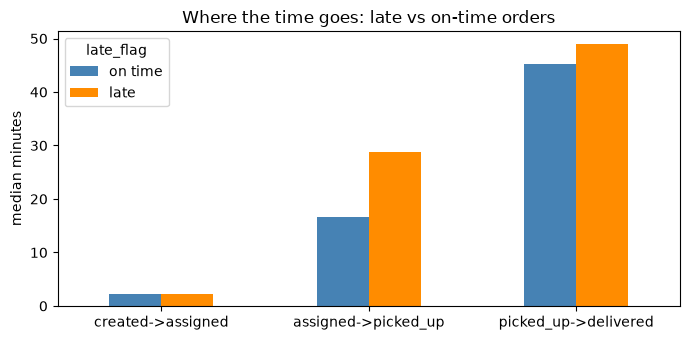

In [14]:
# where does the time go? phase medians for late vs on-time orders (driver app + order_events)
drv = driver_events[driver_events.type != "gps_ping"].pivot_table(index="order_id", columns="type", values="timestamp", aggfunc="first")
drv = drv.apply(lambda c: pd.to_datetime(c, format="mixed"))
ph = ev.join(drv[["assigned"]])
ph["created->assigned"] = (ph.assigned - ph.ORDER_CREATED).dt.total_seconds() / 60
ph["assigned->picked_up"] = (ph.PICKED_UP - ph.assigned).dt.total_seconds() / 60
ph["picked_up->delivered"] = (ph.DELIVERED - ph.PICKED_UP).dt.total_seconds() / 60
phase_tbl = (ph[ph.late_flag.notna()]
             .groupby("late_flag")[["created->assigned", "assigned->picked_up", "picked_up->delivered"]]
             .median().round(1).rename(index={0.0: "on time", 1.0: "late"}))
display(phase_tbl)

phase_tbl.T.plot(kind="bar", figsize=(7, 3.5), rot=0, color=["steelblue", "darkorange"])
plt.ylabel("median minutes")
plt.title("Where the time goes: late vs on-time orders")
plt.tight_layout()
plt.show()

A. Support contact: 88.4% late, 12.7 min avg delay vs 48.6% and 0.8 min without.
Tells: support contact flags late orders. Doesn't prove: support causes delay; more likely lateness makes people contact support.

B. 56.4% late with an intervention (404) and 56.4% without (1091).
Tells: no visible difference today. Doesn't prove: interventions are useless, since they go to orders already at risk.

C. PRIORITY_DISPATCH lowest at 51.2% (86 orders); CUSTOMER_CREDIT highest at 66.7%, and 45 of 63 credits came after delivery.
Tells: priority dispatch is worth testing. Doesn't prove: it works, groups are small and picked for different reasons.

D. R050 has the most late orders (22 of 35); R024 has the highest rate of the top ones (80.0%).
Tells: where to look first. Doesn't prove: the restaurant is at fault, the wait could be the driver.

E. 67 journeys had support + intervention + still late (26 with DRIVER_REASSIGNMENT).
Tells: a good list to review by hand. Doesn't prove: the interventions failed, there's no comparison group.

Extra: late orders take 28.8 min from assignment to pickup vs 16.7 for on-time ones; the ride is 48.9 vs 45.3.

# Challenge 6 — Connect the model to the KPI

Create a one-page project view:

`PROJECT KPI → OUTCOME METRIC → WORKFLOW/DRIVER METRICS → INTERVENTIONS → DATA SOURCES/EVENTS`

Answer:
1. Which metrics are directly controllable by operations?
2. Which are outcomes?
3. Which missing event limits the model most?
4. What would you instrument next?

Final deliverable:
- core entities,
- key events,
- relationships,
- 3–5 metrics,
- KPI linkage,
- one modelling limitation.

```
KPI            Late Delivery Rate 56.39% (> 10 min: 23.34%)
OUTCOME        late_flag, delay_min per order            <- order_outcomes
DRIVERS        order->pickup 26.1 min (late 31.9 / on time 19.8)   <- order_events, driver_events
               support contact on late orders 30.60%     <- app actions, tickets
INTERVENTIONS  priority dispatch, restaurant contact, reassignment (prevent), credit (recover)
               coverage 23.61%, before pickup 58.84%      <- order_interventions
SOURCES        orders db, order_events, driver_events, restaurant_status,
               customer_app_actions, support_tickets, order_interventions, order_outcomes
```

1. Controllable by ops: intervention coverage and timing, which intervention is used, assignment speed. Pickup wait only partly (restaurant involved).
2. Outcomes: late rate, > 10 min rate, delay_min, and support contact as the customer reaction.
3. Biggest missing event: driver arrived at restaurant / food ready. Late orders lose their time in exactly that gap.
4. Next: arrival geofence event, food-ready from the restaurant system, ETA history, and an intervention log that matches dispatch (only 8 of 155 reassignments show a driver change).

**Deliverable**
- Entities: customer, order, order_event, customer_interaction, support_ticket, intervention, order_outcome.
- Key events: ORDER_CREATED, DRIVER_ASSIGNED, PICKED_UP, DELIVERED, ETA_VIEWED, SUPPORT_OPENED, CANCEL_ATTEMPTED, SUPPORT_TICKET, INTERVENTION (missing: ARRIVED_AT_RESTAURANT, FOOD_READY).
- Relationships: customer 1-N order, order 1-N events/interactions/tickets/interventions, order 1-1 outcome.
- Metrics: the 5 in Challenge 4, linked to the KPI above.
- Limitation: interventions aren't random, so the model shows association with outcomes, not their effect.

# Final reflection

A strong solution does not produce the largest schema.

It produces the **smallest useful model that explains the workflow and supports the project KPI**.

In [15]:
wf.close()
con.close()